In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [199]:
# Load the dataset from CSV
df = pd.read_csv('C:/Users/IITIEE/Desktop/SOUMEN DAS/Data_set/USA_Housing.csv')
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [200]:
# Summary statistics of the dataset
print(df.describe())

       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.005833   
min        17796.631190             2.644304                   3.236194   
25%        61480.562388             5.322283                   6.299250   
50%        68804.286404             5.970429                   7.002902   
75%        75783.338666             6.650808                   7.665871   
max       107701.748378             9.519088                  10.759588   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                   5000.000000      5000.000000  5.000000e+03  
mean                       3.981330     36163.516039  1.232073e+06  
std                        1.234137      9925.650114  3.531176e+05  
min                        2.000000       172.61

In [201]:
# Check for missing values
print(df.isnull().sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [202]:
df.columns


Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is

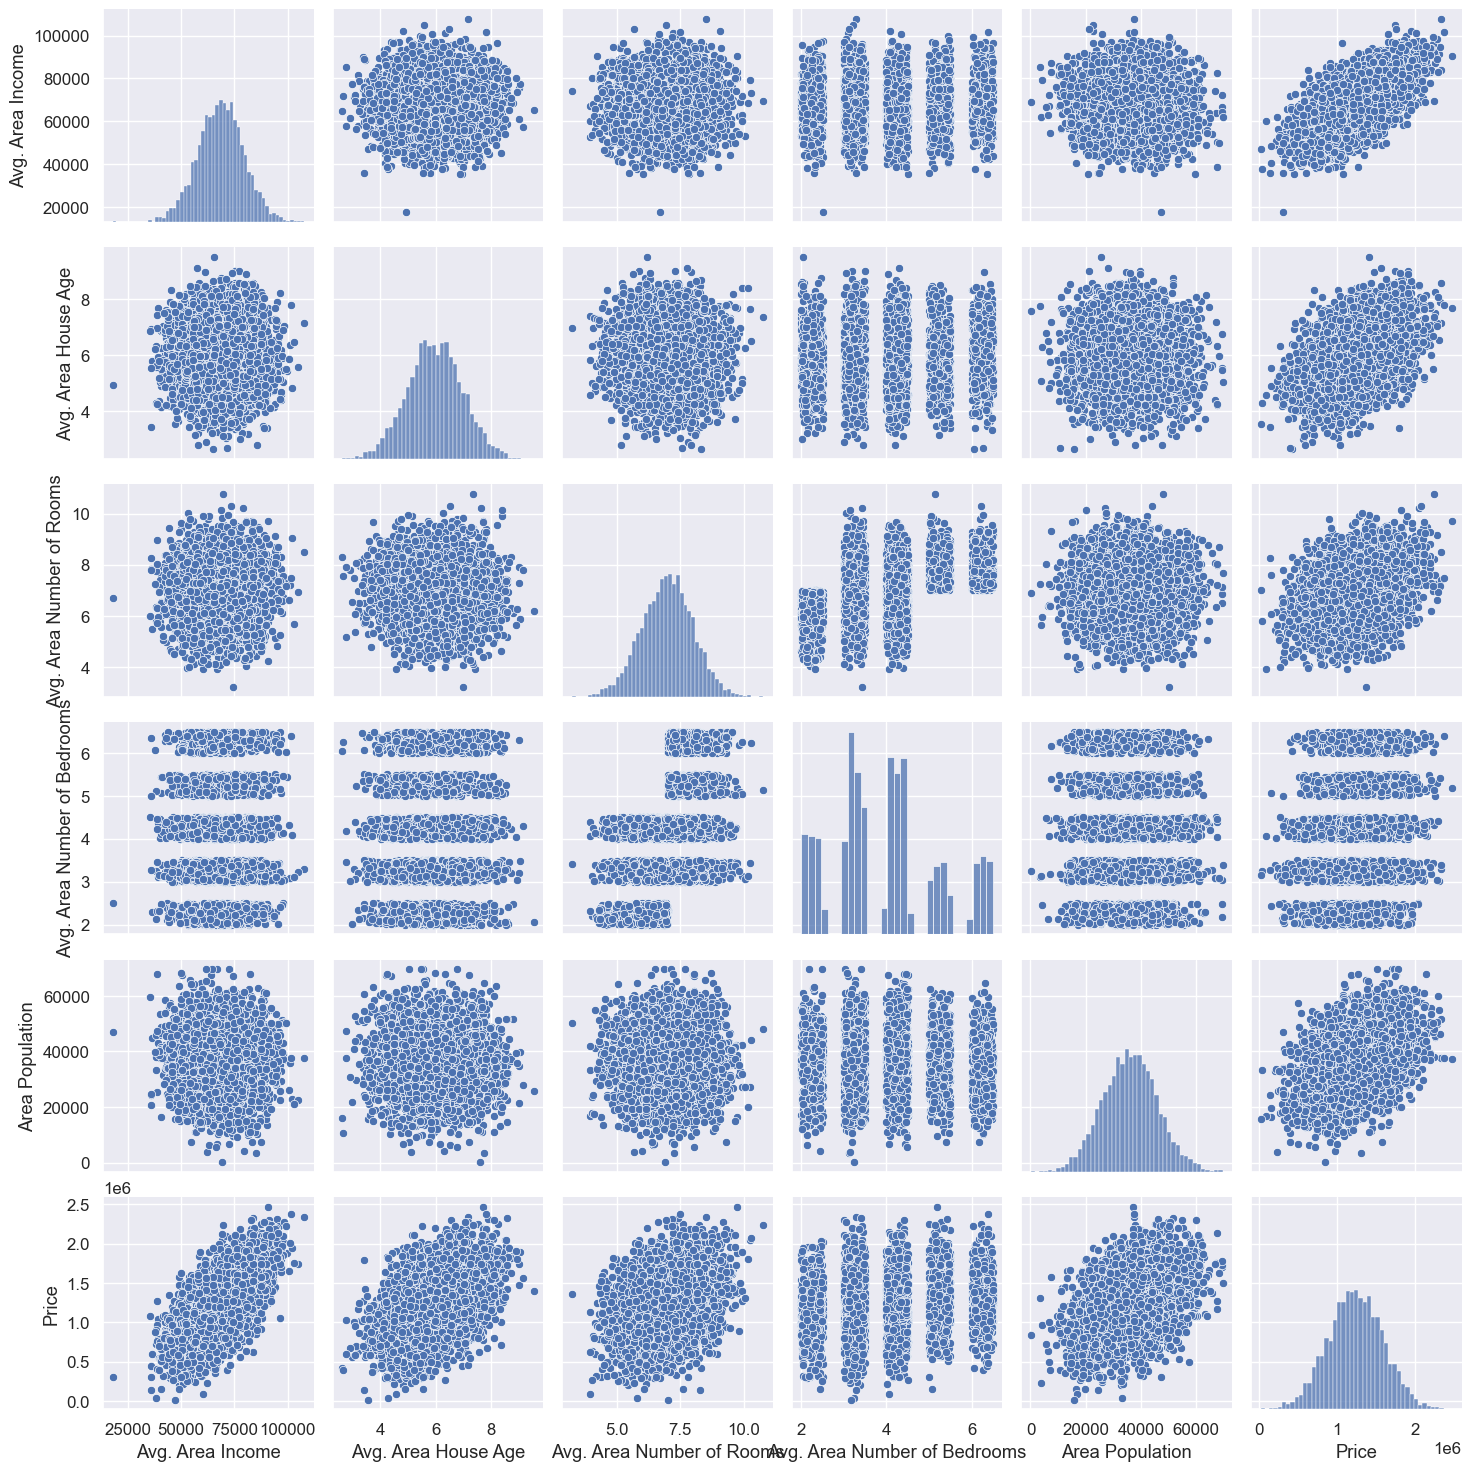

In [203]:
df.drop(['Address'], axis = 1 ,inplace=True)
sns.pairplot(df)

<Axes: >

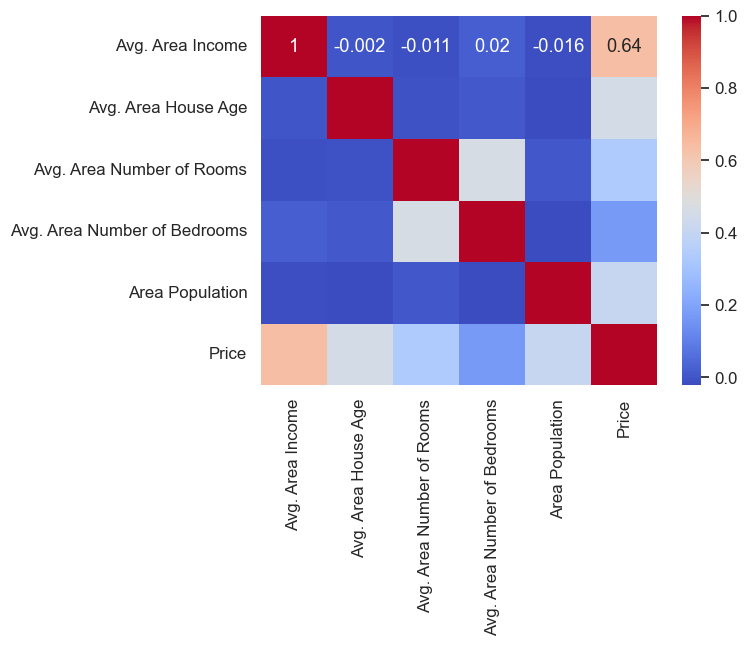

In [204]:
# Correlation matrix to understand feature relationships
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')


In [205]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
print(X)
y = df['Price']
print(y)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population  
0                             4.09     23086.800503  
1  

In [206]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)

# Building the Linear Regression Model
model = LinearRegression()

# Fitting the model on the training data
model.fit(X_train, y_train)

LinearRegression()

In [207]:
from sklearn.metrics import mean_squared_error, r2_score
# Model Evaluation
y_pred = model.predict(X_test)

# Mean Squared Error and R-squared for model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 10100187858.869978
R-squared: 0.9211719165401835


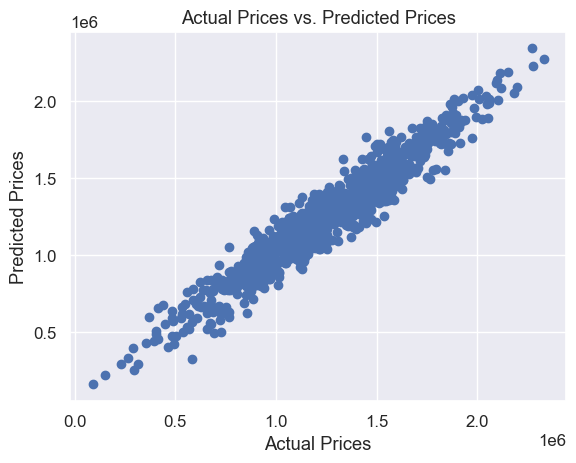

In [208]:
# Predictions and Visualization
# To visualize the predictions against actual prices, we'll use a scatter plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
#plt.plot(y_test,y_pred, color='red',linewidth=1)
plt.show()

C:\Users\IITIEE\AppData\Local\Temp\ipykernel_17864\1072007286.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_pred),bins=50);
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na'

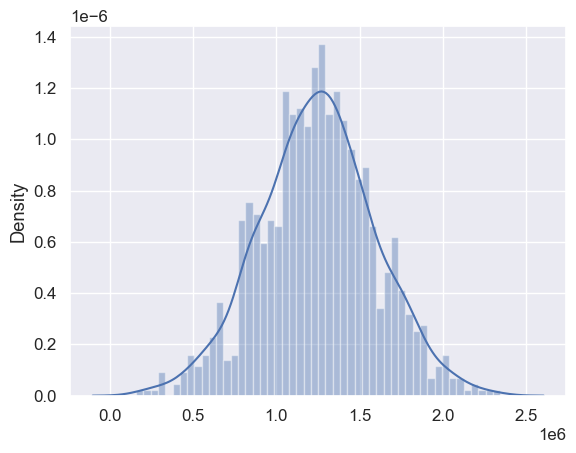

In [209]:
sns.distplot((y_pred),bins=50);

In [210]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test,y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 81305.2330008674
MSE: 10100187858.869978
RMSE: 100499.69083967363


In [211]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
print("Y_Test data\n",y_test,"\n")
print("predicted data \n",y_pred,"\n")


cutoff =1.063964e+06                             # Decide on a cutoff limit

y_test_classes = np.zeros_like(y_pred)
y_test_classes[y_test > cutoff] = 1
print("class label for y_test_classess=\n",y_test_classes)

y_pred_classes = np.zeros_like(y_pred)    # initialise a matrix full with zeros
y_pred_classes[y_pred > cutoff] = 1       # add a 1 if the cutoff was breached
print("\n class label for y_pred_classes=\n",y_pred_classes)


cnf=confusion_matrix(y_test_classes, y_pred_classes)
print(cnf)


TN,FP, FN, TP = cnf.ravel()
print("\n")
print("No of TN =",TN)
print("No of FP =",FP)
print("No of FN =",FN)
print("No of TP =",TP)

Y_Test data
 1718    1.251689e+06
2511    8.730483e+05
345     1.696978e+06
2521    1.063964e+06
54      9.487883e+05
            ...     
3900    1.466412e+06
3753    1.222412e+06
3582    1.404622e+06
2392    9.100996e+05
3343    1.188197e+06
Name: Price, Length: 1000, dtype: float64 

predicted data 
 [1257919.72909702  822112.41884159 1740669.05865521  972452.12917467
  993422.26329271  644126.0741441  1073911.79101603  856584.0019415
 1445318.25518378 1204342.19071248 1455792.46212921 1298556.65696466
 1735924.33836111 1336925.77577769 1387637.43231933 1222403.77772037
  613786.28691901  963933.54416242 1221197.33050125 1198071.575636
  505861.89531603 1769106.54723412 1853881.16842499 1200369.50507915
 1065129.12850722 1812033.73067374 1768686.47091291 1439920.83814319
 1387251.99649402 1541178.39224192  726418.80504193 1754497.60908681
 1462185.7265313  1025600.16081094 1284926.86851569  917454.59590892
 1187046.94956921  999330.91117486 1329536.63409618  782191.60441406
 1393272

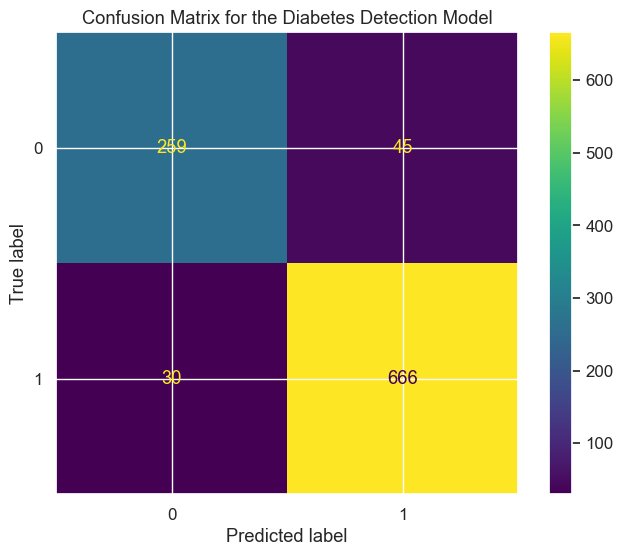

In [212]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Change figure size and increase dpi for better resolution
# and get reference to axes object
fig, ax = plt.subplots(figsize=(8,6), dpi=100)

# initialize using the raw 2D confusion matrix 
# and output labels (in our case, it's 0 and 1)
display = ConfusionMatrixDisplay(cnf)

# set the plot title using the axes object
ax.set(title='Confusion Matrix for the Diabetes Detection Model')

# show the plot. 
# Pass the parameter ax to show customizations (ex. title) 
display.plot(ax=ax);


In [213]:
# Lastly, let's use the trained model to make predictions on new data and visualize the results
new_data = [[59982.197226, 6.002900, 6.730821, 3.09, 40173.072174],[59982.1976, 6.2900, 6.730821, 4.09, 4073.072174]]
predicted_price = model.predict(new_data)

print("Predicted Price:", predicted_price[0])
print("Predicted Price:", predicted_price[1])

Predicted Price: 1079895.8324272083
Predicted Price: 575601.3988966583


C:\Users\IITIEE\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [214]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_classes,  y_pred_classes,zero_division=1))
print("Accuracy:",metrics.accuracy_score(y_test_classes, y_pred_classes.round()))
print("\n")


              precision    recall  f1-score   support

         0.0       0.90      0.85      0.87       304
         1.0       0.94      0.96      0.95       696

    accuracy                           0.93      1000
   macro avg       0.92      0.90      0.91      1000
weighted avg       0.92      0.93      0.92      1000

Accuracy: 0.925


